### check model selection

In [81]:
import torch as th
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

import soft_tex.common.aux_plot

In [2]:
results_path = '../trainings/model_selection.pth'

ms_results_dict  = th.load(results_path)

/tmp/ipykernel_59821/2333748953.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ms_results_dict  = th.load(results_path)


In [3]:
units = list(ms_results_dict['ParallelSoftSensingGRU'].keys())

gru_inference_times = [ms_results_dict['ParallelSoftSensingGRU'][unit]['inference_time']['mean'] for unit in units]
gru_parameters_count = [ms_results_dict['ParallelSoftSensingGRU'][unit]['parameters_count'] for unit in units]

lstm_inference_times = [ms_results_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['mean'] for unit in units]
lstm_parameters_count = [ms_results_dict['ParallelSoftSensingLSTM'][unit]['parameters_count'] for unit in units]

In [4]:
max_param_count = np.max(np.concatenate((gru_parameters_count, lstm_parameters_count)))

gru_norm_parameters_count = np.array(gru_parameters_count) / max_param_count
lstm_norm_parameters_count = np.array(lstm_parameters_count) / max_param_count
gru_norm_parameters_count, lstm_norm_parameters_count

(array([0.01821939, 0.05894212, 0.20812439, 0.77743618]),
 array([0.02346093, 0.07587632, 0.26779729, 1.        ]))

In [5]:
def get_model_performance(selection_dict):
    gru_performance_dict = {}

    for unit in units:
        histories = selection_dict[unit]['histories']

        last_tr_losses = [history['training_losses'][-1] for history in histories]
        last_vl_losses = [history['validation_losses'][-1] for history in histories]
        
        gru_performance_dict[unit] = {}
        gru_performance_dict[unit]['mean_tr_loss'] = np.mean(last_tr_losses)
        gru_performance_dict[unit]['std_tr_loss'] = np.std(last_tr_losses)
        gru_performance_dict[unit]['mean_vl_loss'] = np.mean(last_vl_losses)
        gru_performance_dict[unit]['std_vl_loss'] = np.std(last_vl_losses)

    return gru_performance_dict

gru_performance_dict = get_model_performance(ms_results_dict['ParallelSoftSensingGRU'])
lstm_performance_dict = get_model_performance(ms_results_dict['ParallelSoftSensingLSTM'])

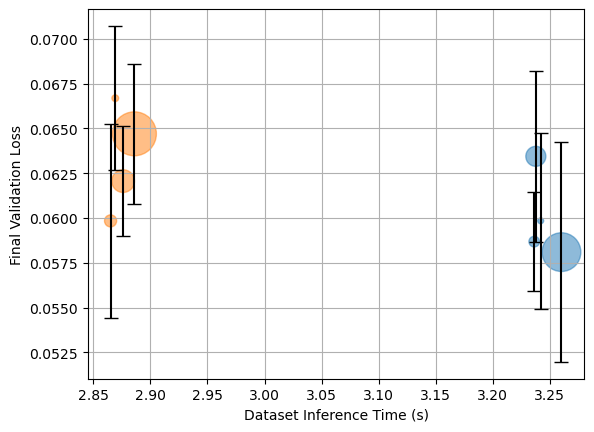

In [6]:
gru_vl_losses = np.array([gru_performance_dict[unit]['mean_vl_loss'] for unit in units])
gru_vl_std_losses = np.array([gru_performance_dict[unit]['std_vl_loss'] for unit in units])
lstm_vl_losses = np.array([lstm_performance_dict[unit]['mean_vl_loss'] for unit in units])
lstm_vl_std_losses = np.array([lstm_performance_dict[unit]['std_vl_loss'] for unit in units])

plt.scatter(x=gru_inference_times, y=gru_vl_losses, s=1e3*gru_norm_parameters_count, alpha=0.5)
plt.scatter(x=lstm_inference_times, y=lstm_vl_losses, s=1e3*lstm_norm_parameters_count, alpha=0.5)

# plot std as error line
plt.errorbar(x=gru_inference_times, y=gru_vl_losses, yerr=gru_vl_std_losses, linestyle='', c='black', barsabove=True, capsize=5)
plt.errorbar(x=lstm_inference_times, y=lstm_vl_losses, yerr=lstm_vl_std_losses, linestyle='', c='black', barsabove=True, capsize=5)

#plt.xscale('log')
#plt.yscale('log')
plt.ylabel('Final Validation Loss')
plt.xlabel('Dataset Inference Time (s)')
plt.grid()
plt.show()

In [7]:
gru_tr_losses = np.array([gru_performance_dict[unit]['mean_tr_loss'] for unit in units])
gru_tr_std_losses = np.array([gru_performance_dict[unit]['std_tr_loss'] for unit in units])
lstm_tr_losses = np.array([lstm_performance_dict[unit]['mean_tr_loss'] for unit in units])
lstm_tr_std_losses = np.array([lstm_performance_dict[unit]['std_tr_loss'] for unit in units])

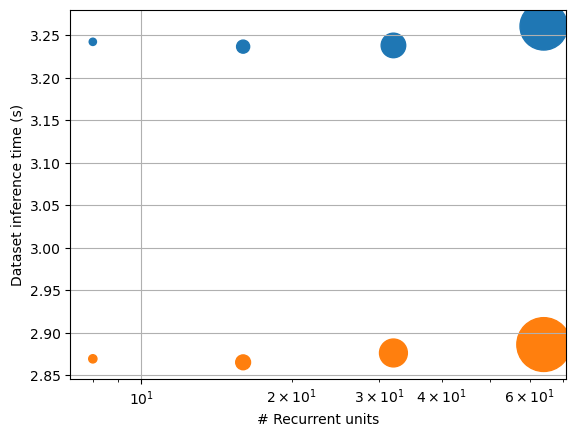

In [8]:
plt.scatter(x=units, y=gru_inference_times, marker='o', s=1.5e3*gru_norm_parameters_count)
plt.scatter(x=units, y=lstm_inference_times, marker='o', s=1.5e3*lstm_norm_parameters_count)

plt.xscale('log')
plt.grid()
plt.ylabel('Dataset inference time (s)')
plt.xlabel('# Recurrent units')
plt.show()

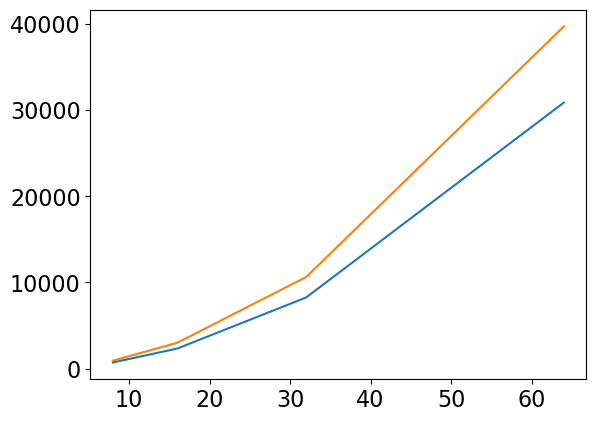

In [ ]:
plt.plot(units, gru_parameters_count)
plt.plot(units, lstm_parameters_count)

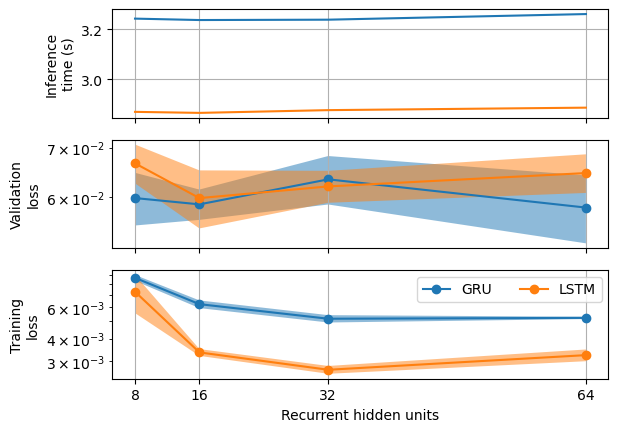

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=True)

# dataset inference time
ax1.plot(units, gru_inference_times)
ax1.plot(units, lstm_inference_times)
ax1.set_ylabel('Inference\ntime (s)')
ax1.grid()

# vl loss
ax2.plot(units, gru_vl_losses, 'o-')
ax2.plot(units, lstm_vl_losses, 'o-')

ax2.fill_between(x=units, y1=gru_vl_losses - gru_vl_std_losses, y2=gru_vl_losses + gru_vl_std_losses, alpha=0.5)
ax2.fill_between(x=units, y1=lstm_vl_losses - lstm_vl_std_losses, y2=lstm_vl_losses + lstm_vl_std_losses, alpha=0.5)
ax2.set_yscale('log')
ax2.set_ylabel('Validation\nloss')
ax2.grid()

# tr loss
ax3.plot(units, gru_tr_losses, 'o-', label='GRU')
ax3.plot(units, lstm_tr_losses, 'o-', label='LSTM')

ax3.fill_between(x=units, y1=gru_tr_losses - gru_tr_std_losses, y2=gru_tr_losses + gru_tr_std_losses, alpha=0.5)
ax3.fill_between(x=units, y1=lstm_tr_losses - lstm_tr_std_losses, y2=lstm_tr_losses + lstm_tr_std_losses, alpha=0.5)
ax3.set_yscale('log')
ax3.set_ylabel('Training\nloss')
ax3.set_xlabel('Recurrent hidden units')
ax3.legend(loc='best', ncols=2)
ax3.set_xticks(units)
ax3.grid()

#### Learning curves

In [ ]:
def get_average_learning_curve(unit, model):
    histories = ms_results_dict[model][unit]['histories']
    tr_loss_trials =  [history['training_losses'] for history in histories]
    vl_loss_trials =  [history['validation_losses'] for history in histories]
    epochs = np.arange(1, len(histories[0]['training_losses']) + 1, 1)

    avg_tr_loss_curve = np.mean(tr_loss_trials, axis=0)
    std_tr_loss_curve = np.std(tr_loss_trials, axis=0)

    avg_vl_loss_curve = np.mean(vl_loss_trials, axis=0)
    std_vl_loss_curve = np.std(vl_loss_trials, axis=0)
    
    return epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve

In [100]:
colors = ['blue', 'orange', 'green', 'red']
models = list(ms_results_dict.keys())
units = list(ms_results_dict[models[0]].keys())

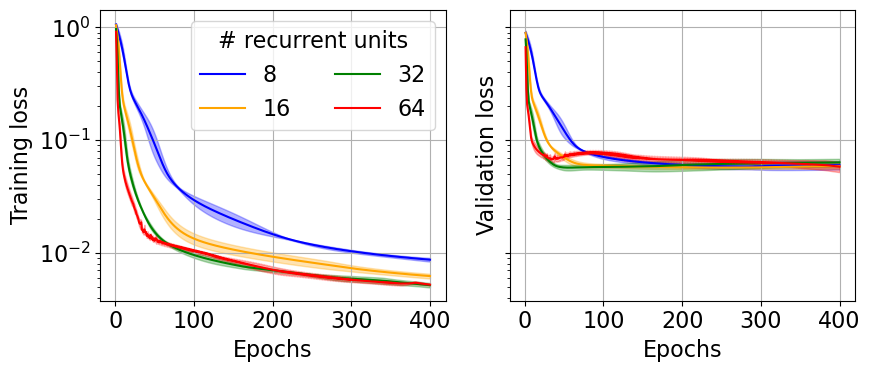

In [101]:
# GRU plots
model = 'ParallelSoftSensingGRU'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True)

for color, unit in zip(colors, units):
    epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve = get_average_learning_curve(unit, model)

    # training loss
    axes[0].plot(epochs, avg_tr_loss_curve, label='%d' % unit, color=color)
    axes[0].fill_between(x=epochs, y1=avg_tr_loss_curve - std_tr_loss_curve, y2=avg_tr_loss_curve + std_tr_loss_curve, color=color, alpha=0.3)
    axes[0].grid(True)
    axes[0].set_ylabel('Training loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend(title='# recurrent units', loc='best', ncols=2)

    # validation loss
    axes[1].plot(epochs, avg_vl_loss_curve, label='%d' % unit, color=color)
    axes[1].fill_between(x=epochs, y1=avg_vl_loss_curve - std_vl_loss_curve, y2=avg_vl_loss_curve + std_vl_loss_curve, color=color, alpha=0.3)
    axes[1].grid(True)
    axes[1].set_ylabel('Validation loss')
    axes[1].set_xlabel('Epochs')

plt.yscale('log')
plt.tight_layout()
plt.show()

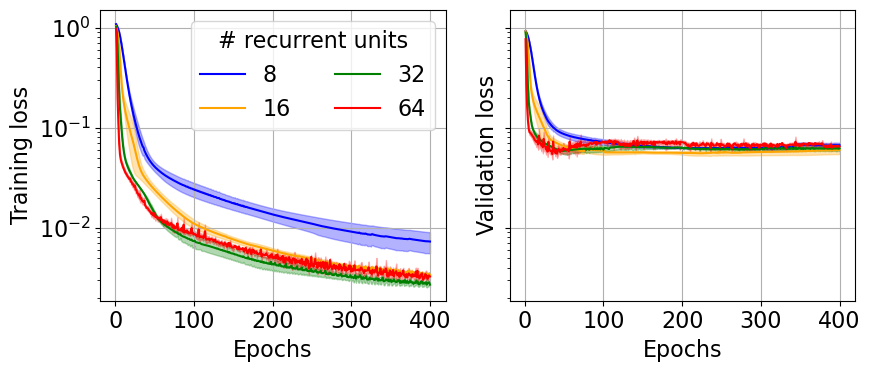

In [102]:
# LSTM plots
model = 'ParallelSoftSensingLSTM'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True)

for color, unit in zip(colors, units):
    epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve = get_average_learning_curve(unit, model)

    # training loss
    axes[0].plot(epochs, avg_tr_loss_curve, label='%d' % unit, color=color)
    axes[0].fill_between(x=epochs, y1=avg_tr_loss_curve - std_tr_loss_curve, y2=avg_tr_loss_curve + std_tr_loss_curve, color=color, alpha=0.3)
    axes[0].grid(True)
    axes[0].set_ylabel('Training loss')
    axes[0].set_xlabel('Epochs')
    axes[0].legend(title='# recurrent units', loc='best', ncols=2)

    # validation loss
    axes[1].plot(epochs, avg_vl_loss_curve, label='%d' % unit, color=color)
    axes[1].fill_between(x=epochs, y1=avg_vl_loss_curve - std_vl_loss_curve, y2=avg_vl_loss_curve + std_vl_loss_curve, color=color, alpha=0.3)
    axes[1].grid(True)
    axes[1].set_ylabel('Validation loss')
    axes[1].set_xlabel('Epochs')

plt.yscale('log')
plt.tight_layout()
plt.show()

### Last training and validation loss

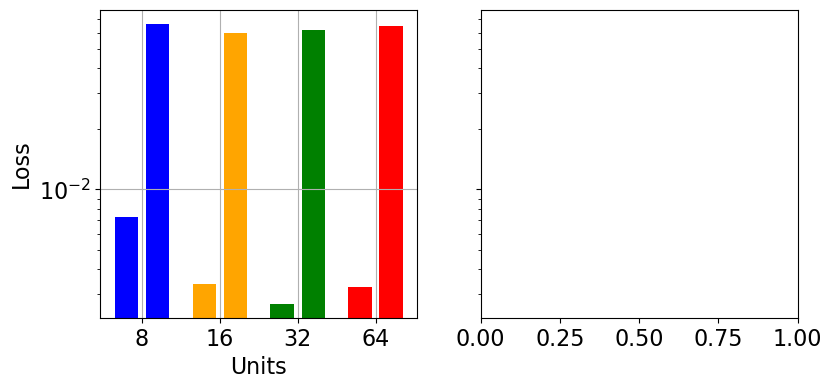

In [134]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True)

for i, (color, unit) in enumerate(zip(colors, units)):
    epochs, avg_tr_loss_curve, std_tr_loss_curve, avg_vl_loss_curve, std_vl_loss_curve = get_average_learning_curve(unit, model)

    # training loss
    axes[0].bar(i-0.2, avg_tr_loss_curve[-1], color=color, width=0.3)
    axes[0].bar(i+0.2, avg_vl_loss_curve[-1], color=color, width=0.3)
    #axes[0].fill_between(x=epochs, y1=avg_tr_loss_curve - std_tr_loss_curve, y2=avg_tr_loss_curve + std_tr_loss_curve, color=color, alpha=0.3)
    axes[0].grid(True)
    axes[0].set_ylabel('Loss')
    axes[0].set_xlabel('Units')
    #axes[0].legend(title='GRU', loc='best', ncols=2)
    #axes[0].set_xticklabels(units)
    axes[0].set_xticks([0,1,2,3], units)
    axes[0].set_yscale('log')
